# Statistical Measures for ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute basic statistical properties of datasets
- Use mean, variance, covariance, correlation
- Apply measures in ML preprocessing and analysis

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — you read the Titanic table's spread and skew off `describe()`; here we define the quantities that summary prints.

**Used later in:** Course 05 (AIAT 115) — Unit 2, lesson 03 "Outliers & Data Transformation" — Z-score and IQR outlier rules are built directly from these.

---


# Statistical Measures for ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 2: Loss Functions** - Understand how to measure error
- ✅ **Basic statistics**: Mean, variance, standard deviation

**If you haven't completed these**, you might struggle with:
- Understanding evaluation metrics
- Understanding R² score

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 03** - how to evaluate models!

**Why this example THIRD?**
- **Before** you can evaluate models, you need loss functions (Example 2)
- **Before** you can compare models, you need metrics

**Builds on**: Example 2 (loss functions)

**Leads to**: Module 05: Statistical Inference

---

## The Story: Understanding Before Using

Imagine you're judging a competition. **Before** you can judge, you need criteria. **After** understanding statistical measures, you have objective ways to evaluate models!

Same with machine learning: **Before** deploying models, we need to know they work. **After** understanding statistical measures, we can objectively evaluate model performance!

---

## Why This Concept Matters

### Why Statistical Measures Matter in ML

**WHY** are statistical measures essential?

1. **Objective Evaluation**:
   - **WHY**: Need numbers to compare models
   - **HOW**: Compute error metrics
   - **AFTER**: Can objectively compare models

2. **Model Selection**:
   - **WHY**: Need to choose best model
   - **HOW**: Compare metrics
   - **AFTER**: Deploy best model

## Learning Objectives
1. Understand evaluation metrics (MSE, MAE, R²)
2. Compute statistical measures
3. Interpret results
4. Compare model performance

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn to train a REAL model
# whose real errors we will measure.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

Example 1: Statistical Measures
WHY: Need objective way to evaluate models
HOW: Compute error metrics


In [2]:
# Example 1: Statistical Measures on a REAL model's REAL errors
# WHY: Need an objective way to evaluate models
# HOW: Train a model on real data, then compute error metrics on data it never saw

# Real dataset: sklearn's diabetes study - 442 patients, 10 baseline measurements,
# target = a quantitative measure of disease progression one year later.
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)

# Train a plain linear model, then predict on the held-out patients.
model = LinearRegression()
model.fit(X_train, y_train)

targets = y_test                    # what actually happened to those patients
predictions = model.predict(X_test)  # what the model said would happen

print("Example 1: Statistical Measures")
print("=" * 60)
print(f"Held-out patients: {len(targets)}")
print(f"Targets     (first 10): {np.round(targets[:10], 2)}")
print(f"Predictions (first 10): {np.round(predictions[:10], 2)}")

# Basic statistics of the data
print(f"\nMean of targets:     {np.mean(targets):.4f}")
print(f"Variance of targets: {np.var(targets):.4f}")
print(f"Std of targets:      {np.std(targets):.4f}")

# Error metrics for model evaluation
errors = predictions - targets
mse = np.mean(errors**2)
mae = np.mean(np.abs(errors))
rmse = np.sqrt(mse)
r2 = 1 - np.sum(errors**2) / np.sum((targets - np.mean(targets))**2)
correlation = np.corrcoef(targets, predictions)[0, 1]

print(f"\nMSE  (Mean Squared Error):  {mse:.4f}")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R²   (Coefficient of Determination): {r2:.4f}")
print(f"Correlation (targets vs predictions): {correlation:.4f}")

print(f"\nRead these honestly: RMSE of {rmse:.1f} is on the target's own scale "
      f"(targets range {targets.min():.0f}-{targets.max():.0f}),")
print(f"and R² = {r2:.2f} means the model explains only about {r2:.0%} of the variation "
      "between patients.")
print("Real data rarely gives a near-perfect score - which is exactly why we measure.")

print(f"\n💡 WHY: Need objective way to evaluate models")
print(f"💡 HOW: Compute error metrics (MSE, MAE, RMSE, R²)")
print(f"💡 AFTER: Can compare models objectively")


Example 1: Statistical Measures
Held-out patients: 89
Targets     (first 10): [219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]
Predictions (first 10): [139.55 179.52 134.04 291.42 123.79  92.17 258.23 181.34  90.22 108.63]

Mean of targets:     145.7753
Variance of targets: 5298.1517
Std of targets:      72.7884

MSE  (Mean Squared Error):  2900.1936
MAE  (Mean Absolute Error): 42.7941
RMSE (Root MSE):            53.8534
R²   (Coefficient of Determination): 0.4526
Correlation (targets vs predictions): 0.6780

Read these honestly: RMSE of 53.9 is on the target's own scale (targets range 37-310),
and R² = 0.45 means the model explains only about 45% of the variation between patients.
Real data rarely gives a near-perfect score - which is exactly why we measure.

💡 WHY: Need objective way to evaluate models
💡 HOW: Compute error metrics (MSE, MAE, RMSE, R²)
💡 AFTER: Can compare models objectively


---

## 📊 Visualization

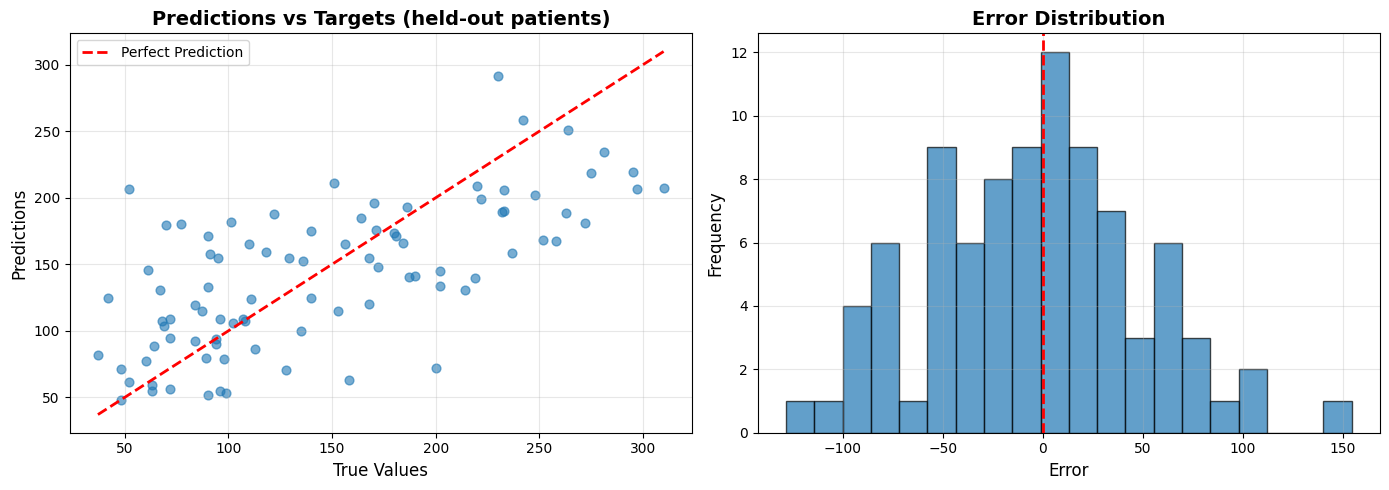


📊 Visualization:
  - Left: How close predictions are to targets
  - Right: Distribution of errors


In [3]:
# Two standard diagnostic plots: predictions vs targets, and the error histogram.
# Together they show not just HOW MUCH the model errs but WHERE and in which direction.

# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: perfect predictions would sit on the red dashed diagonal.
axes[0].scatter(targets, predictions, s=40, alpha=0.6)
axes[0].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('True Values', fontsize=12)
axes[0].set_ylabel('Predictions', fontsize=12)
axes[0].set_title('Predictions vs Targets (held-out patients)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: errors centered on zero mean no systematic bias.
errors = predictions - targets
axes[1].hist(errors, bins=20, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Error Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Left: How close predictions are to targets")
print("  - Right: Distribution of errors")

---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding statistical measures:

1. **Model Evaluation**: Can objectively evaluate models
2. **Model Comparison**: Can compare different models
3. **Model Selection**: Can choose best model
4. **Next Steps**: Learn statistical inference (Module 05)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Willmott, C. J., & Matsuura, K. (2005). *Advantages of the Mean Absolute Error (MAE) over the Root Mean Square Error (RMSE) in Assessing Average Model Performance*. Climate Research, 30, 79–82.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 3: Linear Regression. Springer. <https://www.statlearning.com/>
3. Chicco, D., Warrens, M. J., & Jurman, G. (2021). *The Coefficient of Determination R-squared Is More Informative than SMAPE, MAE, MAPE, MSE and RMSE in Regression Analysis Evaluation*. PeerJ Computer Science, 7, e623. <https://doi.org/10.7717/peerj-cs.623>